# Assignment 2

## Formalia:

Please read the [assignment overview page](https://github.com/suneman/socialdata2026/wiki/Assignments) carefully before proceeding. This page contains information about formatting (including formats etc.), group sizes, and many other aspects of handing in the assignment. 

_If you fail to follow these simple instructions, it will negatively impact your grade!_

**Due date and time**: 
 - The assignment is due on Monday April 6th, 2026 at 23:55. 
 - Hand via DTU Learn. 
 - You should simply hand in the link to the github page with your short data story. (You can't hand in a link directly, so just put the link to your website in a text file and upload that).

## A2: A short data story

This assignment is to create a short data-story based on the work we've done in class so far. In particular you will solve *Exercise 2.1* from *Week 8, Part 2*. The exercises for that week contain full details on how the story should be constructed.

You will need to think about how you place that page on your personal github page (there are several ways of doing that and it's not hard. It's OK to ask an LLM for help). At some point you'll also need to host your final project there, so keep that in mind too.

In [13]:
import pandas as pd

# Load the merged dataset with the correct delimiter
df = pd.read_csv("../files/Police_Department_Incident_Reports__2018_to_Present_20260204.csv", delimiter=';', on_bad_lines='skip')
print(df.columns)

# Print unique crime types
print("Unique crime types:")
print(df["Incident Category"].unique())
print()

# Print unique districts
print("Police districts:")
print(df['Police District'].unique())
print()

# Print start and end date
print("Date range:")
dates = pd.to_datetime(df['Incident Date'])
print(f"Start date: {dates.min().date()}")
print(f"End date: {dates.max().date()}")

C:\Users\45422\AppData\Local\Temp\ipykernel_10100\1091288905.py:4: DtypeWarning: Columns (18,21,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../files/Police_Department_Incident_Reports__2018_to_Present_20260204.csv", delimiter=';', on_bad_lines='skip')


Index(['Row ID', 'Incident Datetime', 'Incident Date', 'Incident Time',
       'Incident Year', 'Incident Day of Week', 'Report Datetime',
       'Incident ID', 'Incident Number', 'CAD Number', 'Report Type Code',
       'Report Type Description', 'Filed Online', 'Incident Code',
       'Incident Category', 'Incident Subcategory', 'Incident Description',
       'Resolution', 'Intersection', 'CNN', 'Police District',
       'Analysis Neighborhood', 'Supervisor District',
       'Supervisor District 2012', 'Latitude', 'Longitude', 'Point',
       'data_as_of', 'data_loaded_at'],
      dtype='object')
Unique crime types:
['Recovered Vehicle' 'Assault' 'Fraud' 'Larceny Theft' 'Lost Property'
 'Motor Vehicle Theft' 'Miscellaneous Investigation' 'Malicious Mischief'
 'Other Miscellaneous' 'Arson' 'Warrant' 'Disorderly Conduct'
 'Suspicious Occ' 'Drug Offense' 'Burglary' 'Courtesy Report'
 'Traffic Violation Arrest' 'Forgery And Counterfeiting' nan
 'Non-Criminal' 'Robbery' 'Other' 'Case Clos

C:\Users\45422\AppData\Local\Temp\ipykernel_10100\816091742.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  civil_sidewalk['Year'] = pd.to_datetime(civil_sidewalk['Incident Date'], errors='coerce').dt.year


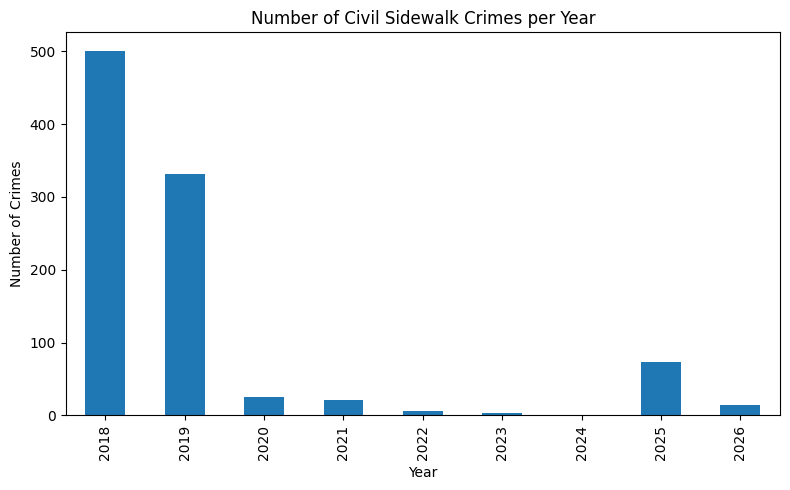

In [14]:
# Temporal analysis: Crimes per year for 'Civil Sidewalk' crime
import matplotlib.pyplot as plt

# Filter for 'Civil Sidewalk' crimes (adjust if the name is slightly different)
civil_sidewalk = df[df['Incident Category'].str.lower().str.contains('civil sidewalk', na=False)]

# Extract year from 'Incident Date'
civil_sidewalk['Year'] = pd.to_datetime(civil_sidewalk['Incident Date'], errors='coerce').dt.year

# Count crimes per year
year_counts = civil_sidewalk['Year'].value_counts().sort_index()

# Plot
plt.figure(figsize=(8,5))
year_counts.plot(kind='bar')
plt.title('Number of Civil Sidewalk Crimes per Year')
plt.xlabel('Year')
plt.ylabel('Number of Crimes')
plt.tight_layout()
plt.show()

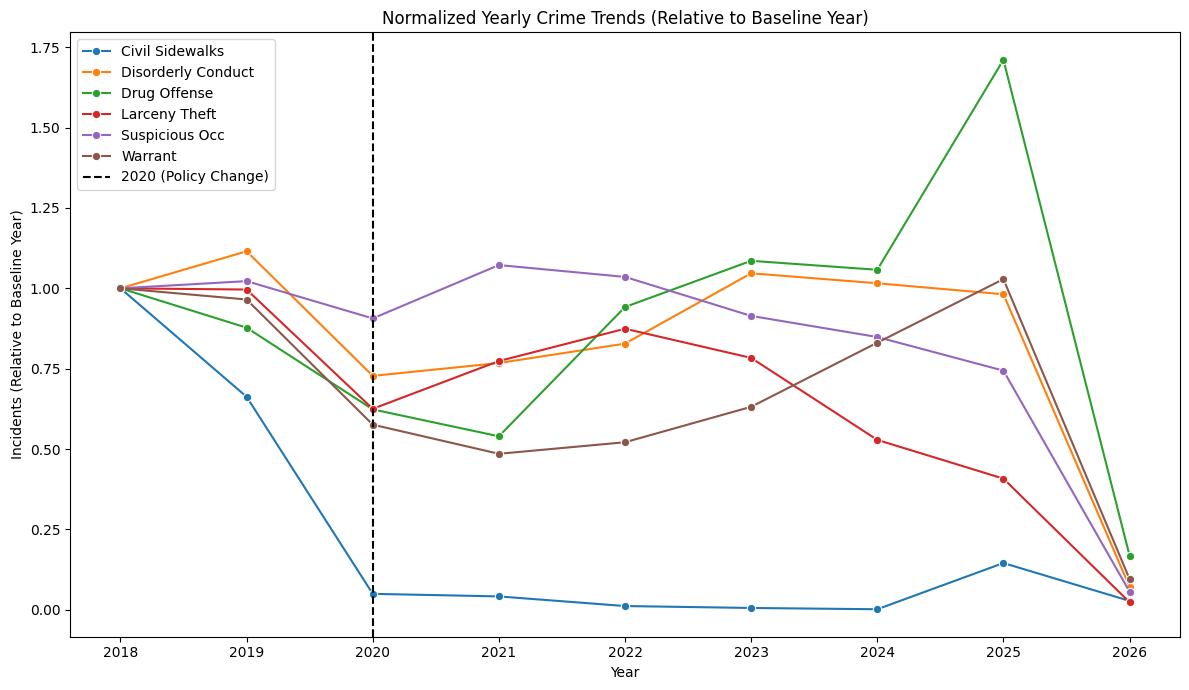

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the crime categories of interest
categories = [
    'Civil Sidewalks',
    'Disorderly Conduct',
    'Drug Offense',
    'Warrant',
    'Larceny Theft',
    'Suspicious Occ'
]

# Filter the DataFrame
trend_df = df[df['Incident Category'].isin(categories)].copy()

# Extract year
trend_df['Year'] = pd.to_datetime(trend_df['Incident Date'], errors='coerce').dt.year

# Group by Year and Incident Category
yearly_counts = (
    trend_df.groupby(['Year', 'Incident Category'])
    .size()
    .reset_index(name='Count')
)

# Normalize counts relative to the first available year for each category
baseline = yearly_counts.groupby('Incident Category').first().reset_index()[['Incident Category', 'Year', 'Count']]
baseline = baseline.rename(columns={'Count': 'BaselineCount'})
yearly_counts = yearly_counts.merge(baseline[['Incident Category', 'BaselineCount']], on='Incident Category', how='left')
yearly_counts['Normalized'] = yearly_counts['Count'] / yearly_counts['BaselineCount']

# Plot normalized trends
plt.figure(figsize=(12,7))
sns.lineplot(
    data=yearly_counts,
    x='Year',
    y='Normalized',
    hue='Incident Category',
    marker='o'
)
plt.axvline(2020, color='k', linestyle='--', label='2020 (Policy Change)')
plt.title('Normalized Yearly Crime Trends (Relative to Baseline Year)')
plt.ylabel('Incidents (Relative to Baseline Year)')
plt.xlabel('Year')
plt.legend()
plt.tight_layout()
plt.show()

## Comparing Yearly Trends for Selected Crime Types

This analysis compares the yearly trends of several crime categories, with normalization to make relative drops visually comparable.

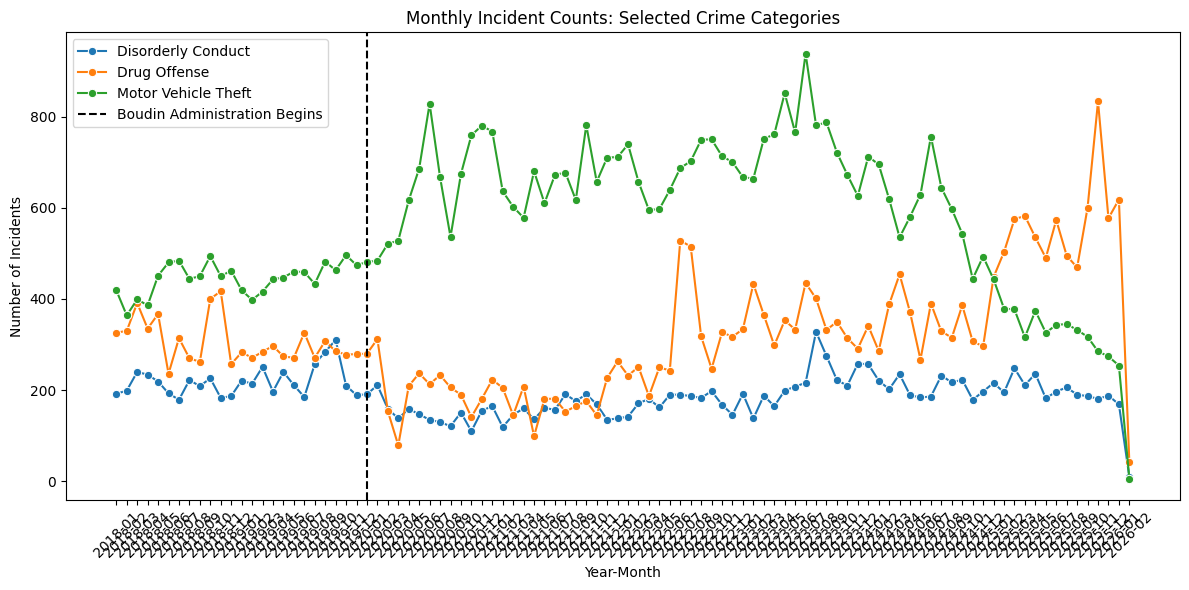

In [15]:
# --- ANALYSIS 1: Volume Comparison (Discretionary vs. Baseline Crimes) ---
import seaborn as sns

# Ensure Incident Date is datetime and create YearMonth
sfpd_df = df.copy()
sfpd_df['Incident Date'] = pd.to_datetime(sfpd_df['Incident Date'], errors='coerce')
sfpd_df['YearMonth'] = sfpd_df['Incident Date'].dt.to_period('M').astype(str)

# Filter for selected categories
categories = ['Drug Offense', 'Disorderly Conduct', 'Motor Vehicle Theft']
vol_df = sfpd_df[sfpd_df['Incident Category'].isin(categories)].copy()

# Group by YearMonth and Incident Category
vol_counts = (
    vol_df.groupby(['YearMonth', 'Incident Category'])
    .size()
    .reset_index(name='Count')
)

# Plot multi-line time series
plt.figure(figsize=(12,6))
sns.lineplot(
    data=vol_counts,
    x='YearMonth',
    y='Count',
    hue='Incident Category',
    marker='o'
)
plt.axvline('2020-01', color='k', linestyle='--', label='Boudin Administration Begins')
plt.title('Monthly Incident Counts: Selected Crime Categories')
plt.xlabel('Year-Month')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

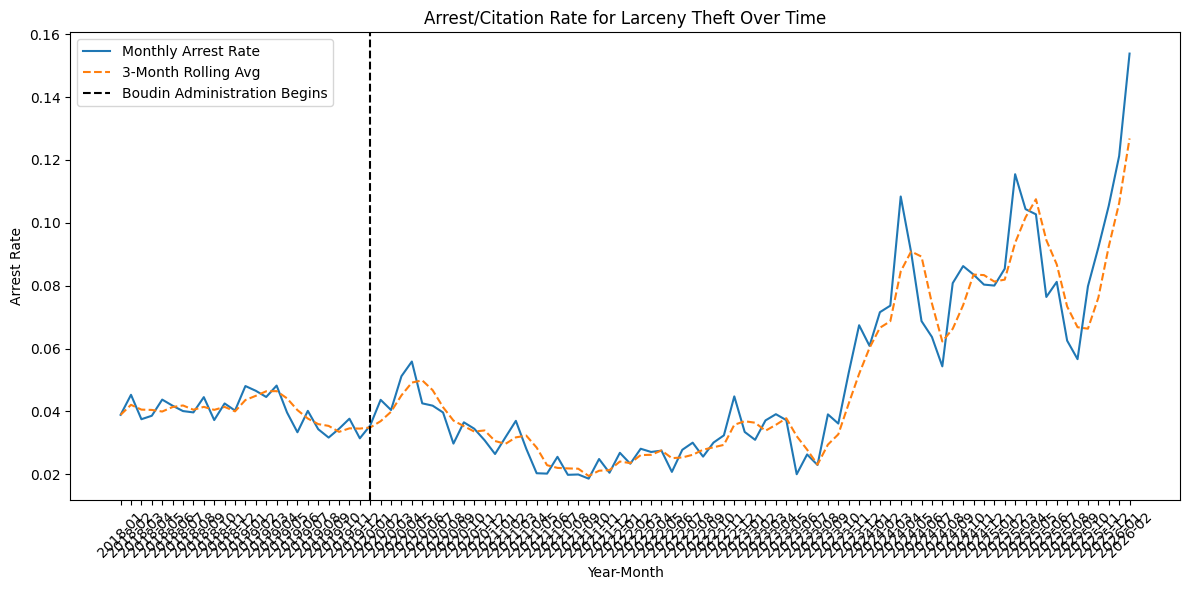

In [16]:
# --- ANALYSIS 2: The Arrest Rate for Larceny/Theft ---
# 1. Filter for Larceny Theft
larceny_df = sfpd_df[sfpd_df['Incident Category'] == 'Larceny Theft'].copy()

# 2. Create Was_Arrested column
larceny_df['Was_Arrested'] = larceny_df['Resolution'].str.contains('arrest|cite', case=False, na=False)

# 3. Group by YearMonth and calculate arrest rate
arrest_rate = (
    larceny_df.groupby('YearMonth')['Was_Arrested']
    .mean()
    .reset_index(name='Arrest Rate')
)

# 4. Add 3-month rolling average
arrest_rate['Arrest Rate (3mo avg)'] = arrest_rate['Arrest Rate'].rolling(window=3, min_periods=1).mean()

# 5. Plot arrest rate over time
plt.figure(figsize=(12,6))
sns.lineplot(data=arrest_rate, x='YearMonth', y='Arrest Rate', label='Monthly Arrest Rate')
sns.lineplot(data=arrest_rate, x='YearMonth', y='Arrest Rate (3mo avg)', label='3-Month Rolling Avg', linestyle='--')
plt.axvline('2020-01', color='k', linestyle='--', label='Boudin Administration Begins')
plt.title('Arrest/Citation Rate for Larceny Theft Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Arrest Rate')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Analysis 2: Arrest Rate for Larceny/Theft

# SFPD Incident Reports: Discretionary vs. Baseline Crimes & Arrest Rate Analysis

This section performs two analyses on the San Francisco Police Department Incident Reports dataset:

1. **Volume Comparison**: Trends in selected crime categories over time, with a policy change marker.
2. **Arrest Rate for Larceny/Theft**: Trends in arrest/citation rates for larceny/theft, including a rolling average.